<a href="https://colab.research.google.com/github/vugaer/ml-models/blob/main/well_logs_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download the dataset from kaggle

In [140]:
# If you want to Download the dataset, please uncomment following lines

import kagglehub
download_path = kagglehub.dataset_download("faresazzam/well-logs-dataset-for-machine-learning")
!mv {download_path}/* ./
!rm -rf sample_data  # Delete stuff comes with colab in every startup

Using Colab cache for faster access to the 'well-logs-dataset-for-machine-learning' dataset.
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/15_9_14_well.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/15_9-23.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/16_2-7.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/16_7-6.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/17_4-1.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_10_10_well.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_10-9.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_11_24_well.csv': Read-only file system
mv: cannot remove '/kaggle/in

In [141]:
# Let's check if our datasets are downloaded to our main
!ls -l

total 60140
-rw-r--r-- 1 1000 1000 4969120 Jan 27 10:42  15_9_14_well.csv
-rw-r--r-- 1 1000 1000 2990968 Jan 27 10:42  15_9-23.csv
-rw-r--r-- 1 1000 1000 3138877 Jan 27 10:42  16_2-7.csv
-rw-r--r-- 1 1000 1000 3074241 Jan 27 10:42  16_7-6.csv
-rw-r--r-- 1 1000 1000 3734562 Jan 27 10:42  17_4-1.csv
-rw-r--r-- 1 1000 1000 2546262 Jan 27 10:42  25_10_10_well.csv
-rw-r--r-- 1 1000 1000 2899898 Jan 27 10:42  25_10-9.csv
-rw-r--r-- 1 1000 1000 1129675 Jan 27 10:42  25_11_24_well.csv
-rw-r--r-- 1 1000 1000 2479354 Jan 27 10:42  25_5_3_well.csv
-rw-r--r-- 1 1000 1000 4263886 Jan 27 10:42  29_3_1_well.csv
-rw-r--r-- 1 1000 1000 2017776 Jan 27 10:42  31_2-10.csv
-rw-r--r-- 1 1000 1000 1991834 Jan 27 10:42 '31_2-21 S.csv'
-rw-r--r-- 1 1000 1000 2026646 Jan 27 10:42  31_6-5.csv
-rw-r--r-- 1 1000 1000 1908705 Jan 27 10:42  31_6-8.csv
-rw-r--r-- 1 1000 1000 6007089 Jan 27 10:42  34_10_16_R_well.csv
-rw-r--r-- 1 1000 1000 3154518 Jan 27 10:42 '34_3-2 S.csv'
-rw-r--r-- 1 1000 1000 4554327 Jan 27 10:42

# Data Overview `df1`

In [142]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
df1 = pd.read_csv('15_9-23.csv')
df1.columns

Index(['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION',
       'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC',
       'ROPA', 'RXO', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [144]:
df1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0
3,15/9-23,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,NaN,...,125.159531,334.233185,1.663353,0.024972,NaN,NaN,98.923820,NaN,65000,3.0
4,15/9-23,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,NaN,0.849849,...,107.576691,330.952362,0.989743,0.024527,NaN,NaN,102.242142,NaN,65000,3.0


In [145]:
df1['FORCE_2020_LITHOFACIES_LITHOLOGY'].unique()

array([65000, 65030, 70000, 30000, 99000, 70032, 80000, 90000])

In [146]:
# Let's drop columns with the same value
df1 = df1.loc[:, df1.nunique() > 1]
df1 = df1.drop(['BS'], axis=1)  # Bit Size should not have any effect on Formation Determination
df1.columns

Index(['DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION', 'CALI',
       'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF', 'DTC', 'ROP', 'DTS',
       'DCAL', 'DRHO', 'ROPA', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [147]:
df1.head()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RMED,RDEP,RHOB,...,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,0.878615,NaN,...,0.439925,NaN,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,65000,3.0
1,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,0.874237,NaN,...,0.504055,NaN,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,65000,3.0
2,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,0.869858,NaN,...,0.512960,NaN,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,65000,3.0
3,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,0.865479,NaN,...,0.500070,NaN,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,65000,3.0
4,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,0.849849,0.863804,NaN,...,0.277670,NaN,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,65000,3.0


From the kaggle dataset, we can see that the lithology is encoded

| Code  | Lithology          |
|-------|--------------------|
| 30000 | Sandstone          |
| 65030 | Sandstone/Shale    |
| 65000 | Shale              |
| 80000 | Marl               |
| 74000 | Dolomite           |
| 70000 | Limestone          |
| 70032 | Chalk              |
| 88000 | Halite             |
| 86000 | Anhydrite          |
| 99000 | Tuff               |
| 90000 | Coal               |
| 93000 | Basement           |


In [148]:
lithology_mapping = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    90000: 'Coal'
}
df1['FORCE_2020_LITHOFACIES_LITHOLOGY'] = df1['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_mapping)

In [149]:
df1.isna().sum()

,0
DEPTH_MD,0
X_LOC,0
Y_LOC,0
Z_LOC,0
GROUP,0
FORMATION,0
CALI,0
RMED,54
RDEP,0
RHOB,54


In [150]:
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RMED,RDEP,RHOB,...,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,1518.280,433906.75000,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,0.878615,NaN,...,0.439925,NaN,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,Shale,3.0
1,1518.432,433906.75000,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,0.874237,NaN,...,0.504055,NaN,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,Shale,3.0
2,1518.584,433906.75000,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,0.869858,NaN,...,0.512960,NaN,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,Shale,3.0
3,1518.736,433906.75000,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,0.865479,NaN,...,0.500070,NaN,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,Shale,3.0
4,1518.888,433906.75000,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,0.849849,0.863804,NaN,...,0.277670,NaN,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,Shale,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,VESTLAND GP.,Skagerrak Fm.,8.622439,4.265228,2.660877,2.662135,...,NaN,6.211904,NaN,17.063992,NaN,0.122439,0.050846,21.664633,Sandstone,1.0
11059,3212.168,433933.25000,6459977.0,-3186.674561,VESTLAND GP.,Skagerrak Fm.,8.654653,2.188407,1.651926,2.574645,...,NaN,5.445361,NaN,17.698082,NaN,0.154652,0.050241,23.712538,Sandstone/Shale,1.0
11060,3212.320,433933.25000,6459977.0,-3186.826660,VESTLAND GP.,Skagerrak Fm.,8.596466,1.375046,1.310661,2.484784,...,NaN,5.160233,NaN,22.885672,NaN,0.096466,0.042768,25.760443,Sandstone/Shale,1.0
11061,3212.472,433933.28125,6459977.0,-3186.978271,VESTLAND GP.,Skagerrak Fm.,8.673164,1.166480,1.262026,2.483438,...,NaN,5.000957,NaN,36.670067,NaN,0.173165,0.039578,27.808348,Shale,1.0


In [151]:
categorical_cols = ['GROUP', 'FORMATION', 'FORCE_2020_LITHOFACIES_LITHOLOGY']

for col in categorical_cols:
    le = LabelEncoder()
    df1[col + '_ENCODED'] = le.fit_transform(df1[col])

df1 = df1.drop(columns=categorical_cols)
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RMED,RDEP,RHOB,GR,NPHI,...,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_CONFIDENCE,GROUP_ENCODED,FORMATION_ENCODED,FORCE_2020_LITHOFACIES_LITHOLOGY_ENCODED
0,1518.280,433906.75000,6460000.5,-1493.241821,15.506232,NaN,0.878615,NaN,103.451515,0.439925,...,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,3.0,1,12,6
1,1518.432,433906.75000,6460000.5,-1493.393799,18.524611,NaN,0.874237,NaN,94.124893,0.504055,...,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,3.0,1,12,6
2,1518.584,433906.75000,6460000.5,-1493.545776,18.855669,NaN,0.869858,NaN,93.586487,0.512960,...,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,3.0,1,12,6
3,1518.736,433906.75000,6460000.5,-1493.697754,19.163353,NaN,0.865479,NaN,91.113373,0.500070,...,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,3.0,1,12,6
4,1518.888,433906.75000,6460000.5,-1493.849609,18.489744,0.849849,0.863804,NaN,100.228333,0.277670,...,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,3.0,1,12,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,8.622439,4.265228,2.660877,2.662135,59.231411,NaN,...,NaN,17.063992,NaN,0.122439,0.050846,21.664633,1.0,4,13,4
11059,3212.168,433933.25000,6459977.0,-3186.674561,8.654653,2.188407,1.651926,2.574645,68.286255,NaN,...,NaN,17.698082,NaN,0.154652,0.050241,23.712538,1.0,4,13,5
11060,3212.320,433933.25000,6459977.0,-3186.826660,8.596466,1.375046,1.310661,2.484784,85.151917,NaN,...,NaN,22.885672,NaN,0.096466,0.042768,25.760443,1.0,4,13,5
11061,3212.472,433933.28125,6459977.0,-3186.978271,8.673164,1.166480,1.262026,2.483438,94.557449,NaN,...,NaN,36.670067,NaN,0.173165,0.039578,27.808348,1.0,4,13,6


In [152]:
numerical_cols_with_nans = ['RMED', 'RHOB', 'NPHI', 'PEF', 'DTC', 'DTS', 'ROP', 'ROPA', 'FORCE_2020_LITHOFACIES_CONFIDENCE']
imputer = SimpleImputer(strategy='median')
df1[numerical_cols_with_nans] = imputer.fit_transform(df1[numerical_cols_with_nans])

y = df1['FORCE_2020_LITHOFACIES_LITHOLOGY_ENCODED']
df1 = df1.drop(columns=['FORCE_2020_LITHOFACIES_LITHOLOGY_ENCODED'], axis=1)

In [153]:
scaler = StandardScaler()

df1 = pd.DataFrame(
    scaler.fit_transform(df1),
    columns=df1.columns,
    index=df1.index
)

In [154]:
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_CONFIDENCE,GROUP_ENCODED,FORMATION_ENCODED
0,-1.731044,-1.817284,1.200582,1.731102,2.622195,-0.465092,-0.379078,-0.120819,0.384472,1.067410,0.062101,0.946517,0.462545,0.754230,-5.401892,2.147175,-0.114236,5.147423,-0.793403,0.456113
1,-1.730734,-1.817284,1.200582,1.730792,4.907859,-0.465092,-0.382130,-0.120819,0.184350,1.566143,0.062101,0.891364,0.476673,0.710945,1.877097,-2.144423,-0.060355,5.147423,-0.793403,0.456113
2,-1.730424,-1.817284,1.200582,1.730482,5.158553,-0.465092,-0.385183,-0.120819,0.172797,1.635403,0.062101,0.886883,0.387341,0.739885,2.675461,-1.065763,-0.006475,5.147423,-0.793403,0.456113
3,-1.730115,-1.817284,1.200582,1.730172,5.391546,-0.465092,-0.388235,-0.120819,0.119732,1.535153,0.062101,0.831029,0.182756,0.849790,3.417460,-0.984344,0.047406,5.147423,-0.793403,0.456113
4,-1.729805,-1.817284,1.200582,1.729863,4.881457,-0.403031,-0.389403,-0.120819,0.315312,-0.194452,0.062101,0.803088,-0.047485,0.809502,1.793012,-1.000802,0.101287,5.147423,-0.793403,0.456113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,1.722940,2.109608,-2.105491,-1.722740,-2.590551,1.856118,0.863388,1.909590,-0.564361,0.268744,0.380913,0.474681,-1.232715,0.342530,-0.298540,-0.028112,-1.207078,-0.308214,1.395115,0.689918
11059,1.723250,2.109608,-2.105491,-1.723050,-2.566158,0.482376,0.160020,1.382444,-0.370071,0.268744,-0.369332,0.474681,-1.224412,0.342530,-0.220857,-0.050485,-1.173826,-0.308214,1.395115,0.689918
11060,1.723560,2.109608,-2.105491,-1.723360,-2.610219,-0.055633,-0.077886,0.841009,-0.008184,0.268744,-0.648397,0.474681,-1.156482,0.342530,-0.361175,-0.326648,-1.140573,-0.308214,1.395115,0.689918
11061,1.723870,2.114239,-2.105491,-1.723669,-2.552140,-0.193592,-0.111791,0.832901,0.193631,0.268744,-0.804286,0.474681,-0.975981,0.342530,-0.176213,-0.444558,-1.107321,-0.308214,1.395115,0.689918


In [155]:
X_train, X_test, y_train, y_test = train_test_split(df1, y, test_size=0.6, random_state=42)

## Random Forest Classification

In [156]:
rf_classifier = RandomForestClassifier(max_depth=12, criterion='entropy', random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=12, random_state=42)

In [157]:
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [158]:
print("RandomForestClassifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.96      0.79      0.87        33
           2       0.96      0.94      0.95       994
           3       0.91      0.93      0.92       541
           4       0.93      0.92      0.93       335
           5       0.92      0.94      0.93       627
           6       0.99      0.99      0.99      4046
           7       0.88      0.96      0.92        46

    accuracy                           0.97      6638
   macro avg       0.94      0.91      0.92      6638
weighted avg       0.97      0.97      0.97      6638



In [159]:
print("RandomForestClassifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RandomForestClassifier Confusion Matrix:
[[  13    0    3    0    0    0    0    0]
 [   0   26    0    0    1    6    0    0]
 [   1    0  931   46    0    3   10    3]
 [   0    0   32  504    0    0    5    0]
 [   0    0    0    0  309   22    1    3]
 [   0    1    0    0   20  587   19    0]
 [   0    0    1    3    1   21 4020    0]
 [   0    0    2    0    0    0    0   44]]


## Support Vector Classifier

In [160]:
svc_classifier = SVC(random_state=42, C=100)
svc_classifier.fit(X_train, y_train)

SVC(C=100, random_state=42)

In [161]:
y_pred_svc = svc_classifier.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)

In [162]:
print(f"SVC Accuracy: {accuracy_svc:.4f}")
print(f"RandomForestClassifier Accuracy: {accuracy_rf:.4f}")

SVC Accuracy: 0.9641
RandomForestClassifier Accuracy: 0.9693


In [163]:
print("SVC Classification Report:")
print(classification_report(y_test, y_pred_svc))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.94      0.94      0.94        33
           2       0.96      0.92      0.94       994
           3       0.89      0.93      0.91       541
           4       0.91      0.93      0.92       335
           5       0.92      0.92      0.92       627
           6       0.99      0.99      0.99      4046
           7       0.87      0.98      0.92        46

    accuracy                           0.96      6638
   macro avg       0.90      0.94      0.92      6638
weighted avg       0.96      0.96      0.96      6638



In [164]:
print("SVC Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

SVC Confusion Matrix:
[[  14    0    0    2    0    0    0    0]
 [   0   31    0    0    0    2    0    0]
 [   4    0  919   57    4    0    6    4]
 [   0    0   32  502    0    0    7    0]
 [   0    0    0    0  311   20    1    3]
 [   1    2    0    0   22  577   25    0]
 [   0    0    5    4    5   31 4001    0]
 [   0    0    0    0    0    0    1   45]]


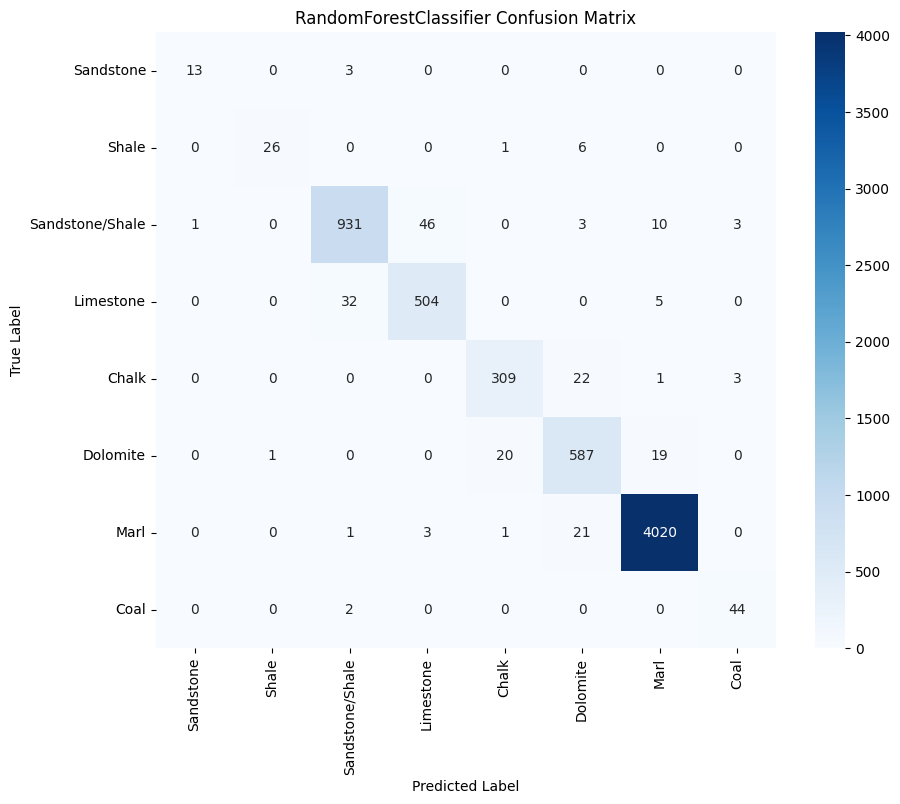

RandomForestClassifier Confusion Matrix heatmap displayed with decoded labels.


In [165]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sorted_items = sorted(lithology_mapping.items())
lithology_names = [item[1] for item in sorted_items]

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=lithology_names, yticklabels=lithology_names)
plt.title('RandomForestClassifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("RandomForestClassifier Confusion Matrix heatmap displayed with decoded labels.")

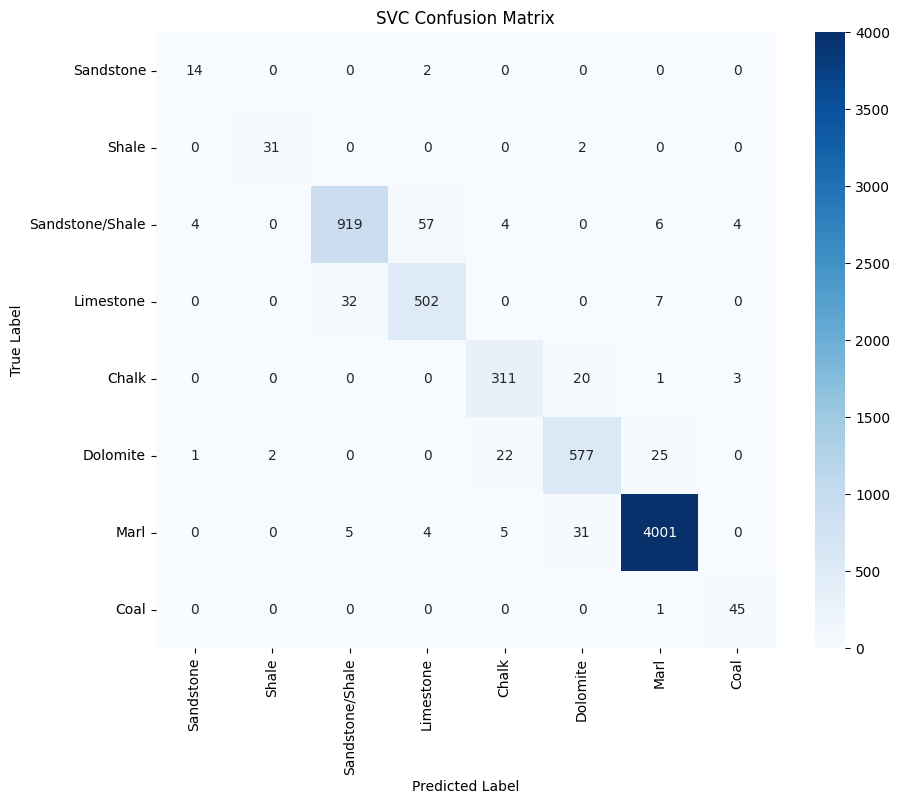

SVC Confusion Matrix heatmap displayed with decoded labels.


In [166]:
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
sorted_items = sorted(lithology_mapping.items())
lithology_names = [item[1] for item in sorted_items]

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues', xticklabels=lithology_names, yticklabels=lithology_names)
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("SVC Confusion Matrix heatmap displayed with decoded labels.")